In [0]:
%pip install --upgrade mlflow tensorflow optuna
dbutils.library.restartPython()

  Attempting uninstall: optuna
    Found existing installation: optuna 4.7.0
    Uninstalling optuna-4.7.0:
      Successfully uninstalled optuna-4.7.0
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd, numpy as np, joblib
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import mlflow
import tensorflow as tf
from tensorflow import keras

In [0]:



#Load data 
df = pd.read_csv('/Volumes/workspace/default/salaries/salaries.csv')
df = df[df['work_year'] <= 2023].reset_index(drop=True)
# Minimal cleanup
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2022,SE,FT,Data Manager,78500,EUR,82477,PL,50,PL,M
1,2022,EN,FT,Software Development Engineer,14400,EUR,15129,RO,50,RO,L
2,2022,EX,FT,Head of Business Intelligence,100000,EUR,105066,IE,100,IE,L
3,2023,EX,FT,Head of Business Intelligence,108000,EUR,116605,IE,100,IE,L
4,2022,SE,FT,Computer Vision Engineer,60000,USD,60000,VN,100,AS,M


**Data Exploration**

We would like to study data drift and how it affects model performance. 
Data drift make happen rapidly after a market shock. In this scenratio we consider a shock due to the introduction of LLM in 2022. This breakthrough changed the demand for AI specialists, their salaries , and the type of companies hiring for these positions.

**AI Related position count between 2020-2023**

In [0]:
df['work_year'].value_counts()

work_year
2023    8522
2022    1659
2021     218
2020      75
Name: count, dtype: int64

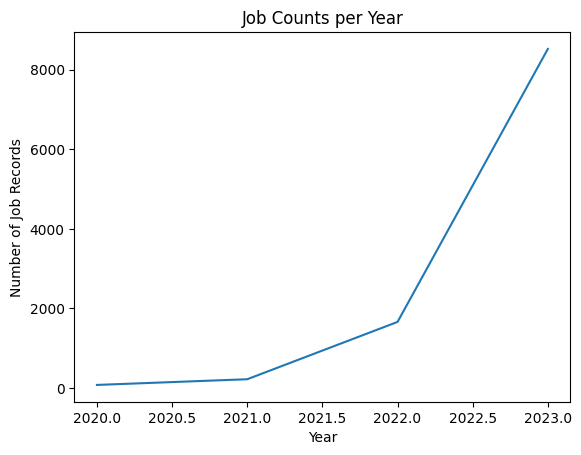

In [0]:
import matplotlib.pyplot as plt

# Count jobs per year
job_counts = df.groupby('work_year').size().sort_index()

plt.figure()
plt.plot(job_counts.index, job_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of Job Records")
plt.title("Job Counts per Year")
plt.show()

**Salary for AI specialists between 2020 and 2023**

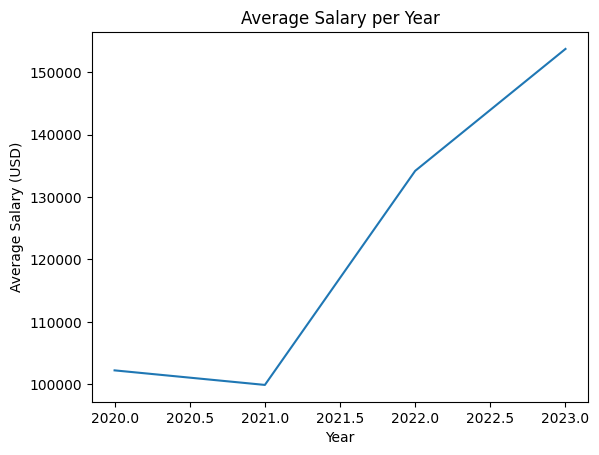

In [0]:
avg_salary = df.groupby('work_year')['salary_in_usd'].mean().sort_index()

plt.figure()
plt.plot(avg_salary.index, avg_salary.values)
plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")
plt.title("Average Salary per Year")
plt.show()

**Feature **Engineering****

In [0]:
# Create simple job groups and ai_flag to analyze AI presence by year
def map_job_group(title):
    t = str(title).lower()
    if 'data scientist' in t or 'data science' in t:
        return 'data_scientist'
    if 'research' in t or 'nlp' in t or 'vision' in t:
        return 'research'
    if 'analyst' in t:
        return 'data_analyst'
    if 'engineer' in t and ('ml' not in t and 'machine' not in t):
        return 'engineer'
    return 'other'


ai_keywords = ['ml','machine learning','deep','nlp','transformer','gpt','bert','llm']
def is_ai_title(title):
    s = str(title).lower()
    return int(any(k in s for k in ai_keywords))

###########NEW FEATURES#########
df['job_group'] = df['job_title'].apply(map_job_group)
df['ai_flag'] = df['job_title'].apply(is_ai_title)



cat_cols = ['experience_level','employment_type','company_size','job_group'] 
num_cols = ['remote_ratio','ai_flag']


**Here we assume that we build a model in 2021 before the AI boom and we only have access to the data prior to 2022**

In [0]:
before_data = df[df['work_year'] <= 2021].reset_index(drop=True)
post_data  = df[df['work_year'] >= 2022].reset_index(drop=True)

In [0]:
# Filter dataset to required columns and drop NA for chosen features
use_cols = cat_cols + num_cols + ['salary_in_usd','work_year']


ohe =OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = ohe.fit_transform(before_data[cat_cols])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(before_data[num_cols])

# Save preprocessing artifacts
ART_DIR='/Volumes/workspace/default/salaries/'
import os
joblib.dump(ohe, os.path.join(ART_DIR,'ohe.joblib'))
joblib.dump(scaler, os.path.join(ART_DIR,'scaler.joblib'))
print("Saved encoders to", ART_DIR)

# Build matrices
X_train_full = np.hstack([X_train_encoded,X_train_scaled])
y_train_full = before_data['salary_in_usd'].values

Saved encoders to /Volumes/workspace/default/salaries/


**Train / Val/ Split**


In [0]:
# validation split from pre-2022 train
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

**Define Model Architecture**


In [0]:
mlflow.tensorflow.autolog(disable=True)  # we will log manually inside trial



def build_keras(hidden, lr, dropout):
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
        keras.layers.Dense(hidden, activation='relu'),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(max(16, hidden//2), activation='relu'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

In [0]:
from sklearn.metrics import root_mean_squared_error
import optuna

##############NUMBER OF OPTUNA TRIALS#############
N_TRIALS=6

###################

def objective(trial):

    hidden = trial.suggest_int("hidden", 32, 256, step=32)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    batch = trial.suggest_categorical("batch_size", [32, 64, 128])
    epochs = trial.suggest_int("epochs", 6, 20)

    with mlflow.start_run(nested=True) as run:

       
        mlflow.log_params(trial.params)              # hyperparams dictionary
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", batch)

        model = build_keras( hidden, lr, dropout)

        try:
            model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                batch_size=batch,
                verbose=0
            )
        except optuna.exceptions.TrialPruned:
            # mark run as pruned and save params/optional intermediate info
            mlflow.set_tag("optuna_pruned", True)
            # (params already logged above, but safe to log again or log a short message)
            mlflow.log_param("pruned", True)
            # re-raise so Optuna still records the trial as pruned
            raise


        preds = model.predict(X_val).ravel()
        rmse = root_mean_squared_error(y_val, preds)

        mlflow.log_metric("val_rmse", rmse) #MlFlow expects a float
        mlflow.keras.log_model(model, name="model")
       
       


        model_uri = f"runs:/{run.info.run_id}/model"
        trial.set_user_attr("mlflow_run_id", run.info.run_id)
        trial.set_user_attr("mlflow_model_uri", model_uri)

    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS)

[I 2026-03-15 02:51:38,239] A new study created in memory with name: no-name-80aa830e-6177-48b8-a1d5-8e7c5537a020
/local_disk0/.ephemeral_nfs/envs/pythonEnv-82ac4f83-5fd4-4087-9a4b-b647749f88aa/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


🔗 View Logged Model at: https://dbc-625693fb-cf65.cloud.databricks.com/ml/experiments/1310860610539561/models/m-9088aea78abf41d7a0ed2ada386612b1?o=2280583005877963
2026/03/15 02:51:42 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/03/15 02:51:49 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.10.1/ml/model/signatures.html for instructions on setting signature on models.
[I 2026-03-15 02:51:50,581] Trial 0 finished with value: 135580.53125 and parameters: {'hidden': 128, 'lr': 0.00047010165906541574, 'dropout': 0.12167968934593609, 'batch_size': 128, 'epochs': 15}. Best is trial 0 with value: 135580.53125.
/local_disk0/.epheme

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


🔗 View Logged Model at: https://dbc-625693fb-cf65.cloud.databricks.com/ml/experiments/1310860610539561/models/m-7927d8fb09a24ff691aa82c449776d77?o=2280583005877963
2026/03/15 02:51:53 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/03/15 02:51:58 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.10.1/ml/model/signatures.html for instructions on setting signature on models.
[I 2026-03-15 02:51:59,340] Trial 1 finished with value: 132360.65625 and parameters: {'hidden': 224, 'lr': 0.003485810045009192, 'dropout': 0.14020788477122892, 'batch_size': 32, 'epochs': 10}. Best is trial 1 with value: 132360.65625.
/local_disk0/.ephemeral

...

🔗 View Logged Model at: https://dbc-625693fb-cf65.cloud.databricks.com/ml/experiments/1310860610539561/models/m-12c1d0fd57854746a8da4b1505405288?o=2280583005877963
2026/03/15 02:52:12 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/03/15 02:52:18 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.10.1/ml/model/signatures.html for instructions on setting signature on models.
[I 2026-03-15 02:52:19,050] Trial 3 finished with value: 135580.15625 and parameters: {'hidden': 96, 'lr': 0.00021959676559911117, 'dropout': 0.05467732552305443, 'batch_size': 64, 'epochs': 20}. Best is trial 1 with value: 132360.65625.
/local_disk0/.ephemera

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


🔗 View Logged Model at: https://dbc-625693fb-cf65.cloud.databricks.com/ml/experiments/1310860610539561/models/m-eb8a4a0d53484dd3b4b2f325b12f15ca?o=2280583005877963
2026/03/15 02:52:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/03/15 02:52:27 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.10.1/ml/model/signatures.html for instructions on setting signature on models.
[I 2026-03-15 02:52:28,067] Trial 4 finished with value: 134999.4375 and parameters: {'hidden': 224, 'lr': 0.0023145390324885145, 'dropout': 0.1447723864669755, 'batch_size': 64, 'epochs': 16}. Best is trial 1 with value: 132360.65625.
/local_disk0/.ephemeral_

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


🔗 View Logged Model at: https://dbc-625693fb-cf65.cloud.databricks.com/ml/experiments/1310860610539561/models/m-00d475181fef4b9da0ab855ab5a98f06?o=2280583005877963
2026/03/15 02:52:31 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/03/15 02:52:36 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.10.1/ml/model/signatures.html for instructions on setting signature on models.
[I 2026-03-15 02:52:37,380] Trial 5 finished with value: 135577.21875 and parameters: {'hidden': 64, 'lr': 0.000929656199291766, 'dropout': 0.07244282462242319, 'batch_size': 64, 'epochs': 16}. Best is trial 1 with value: 132360.65625.


**Record the Best Model**

In [0]:
best = study.best_trial
print("Best trial params:", best.params, "val_rmse:", best.value)
best_run_id = best.user_attrs.get("mlflow_run_id")
best_model_uri = best.user_attrs.get("mlflow_model_uri")
print("Best model uri:", best_model_uri)

Best trial params: {'hidden': 224, 'lr': 0.003485810045009192, 'dropout': 0.14020788477122892, 'batch_size': 32, 'epochs': 10} val_rmse: 132360.65625
Best model uri: runs:/9b9c5881243b49f090f039a2971b7494/model


**Create Model **Signature****

In [0]:
import tempfile 

os.makedirs("/Volumes/workspace/default/salaries/", exist_ok=True)
os.environ["MLFLOW_TMP_DIR"] = "/Volumes/workspace/default/salaries/"
tempfile.tempdir = "/Volumes/workspace/default/salaries/"

best_model = mlflow.keras.load_model(best_model_uri)

from mlflow.models.signature import infer_signature

# sample input
X_sample = X_val[:5]
X_sample_np = np.array(X_sample[:5], dtype=np.float32)
# model output
y_pred_sample = best_model.predict(X_sample)

signature = infer_signature(X_sample_np, y_pred_sample)



with mlflow.start_run(run_name="best_model_final") as run:
    mlflow.keras.log_model(
        best_model,
        name="best_model_sign",
        signature=signature,
     
    )
    
    best_model_uri = f"runs:/{run.info.run_id}/best_model_sign"
    print(f"Model logged at: {best_model_uri}")
    

# Verify signature was captured
logged = mlflow.models.get_model_info(best_model_uri)
print("Logged signature:", logged.signature)  # must not be None

    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


🔗 View Logged Model at: https://dbc-625693fb-cf65.cloud.databricks.com/ml/experiments/1310860610539561/models/m-51aabbd8d43e4cc494a7358464135673?o=2280583005877963


Model logged at: runs:/f2e90e9da9564ee9a11ec44b02ab0709/best_model_sign


Logged signature: inputs: 
  [Tensor('float32', (-1, 18))]
outputs: 
  [Tensor('float32', (-1, 1))]
params: 
  None



Register model in MLFlow

In [0]:
import mlflow
import mlflow.keras
import time
from mlflow.tracking import MlflowClient

client = MlflowClient()
MODEL_NAME = 'ai_salary_nn_final'


new_rmse = client.get_run(best_run_id).data.metrics.get("val_rmse")
print(f"New model val_rmse: {new_rmse:.2f}")


promote = False
try:
    current_version = client.get_model_version_by_alias(MODEL_NAME, "staging")
    current_rmse = client.get_run(current_version.run_id).data.metrics.get("val_rmse")
    print(f"Current staging v{current_version.version} val_rmse: {current_rmse:.2f}")

    if new_rmse < current_rmse:
        promote = True
        print(f"New model is better → will register and promote")
    else:
        print(f"New model is NOT better → skipping registration")
except Exception:
    promote = True
    print("No current staging model — will register and promote")

#Only register AND promote if better
if promote:
    try:
        client.create_registered_model(MODEL_NAME)
    except Exception:
        pass  # already exists

    mv = client.create_model_version(
        name=MODEL_NAME,
        source=best_model_uri,
        run_id=best_run_id
    )

    for _ in range(10):
        mv = client.get_model_version(MODEL_NAME, mv.version)
        if mv.status == "READY":
            break
        time.sleep(3)

    client.set_registered_model_alias(MODEL_NAME, "staging", mv.version) 
    print(f"Registered v{mv.version} | Status: {mv.status}")
    print(f"Alias 'staging' v{mv.version}")
else:
    print(f"ℹNo changes to registry: alias 'staging' unchanged  v{current_version.version}")

New model val_rmse: 132360.66
Current staging v2 val_rmse: 133902.78
New model is better → will register and promote


Uploading artifacts:   0%|          | 0/10 [00:00<?, ?it/s]

✅ Registered v3 | Status: READY
✅ Alias 'staging' → v3


**Evaluate Model performace on Post 2022 Data**


**Test**

Here we intentially use test from after 2022. Let's see if the marklet changes affected teh performance of the model. If so, we would epxect validation accuracy to be different from test accuracy

In [0]:
#Use scaler and encoder fitted on train data
X_post_encoded = ohe.transform(post_data[cat_cols]) if len(cat_cols)>0 else np.zeros((len(post_data),0))
X_post_scaled = scaler.transform(post_data[num_cols]) if len(num_cols)>0 else np.zeros((len(post_data),0))
X_test_post = np.hstack([X_post_encoded, X_post_scaled])
y_test_post = post_data['salary_in_usd'].values

#Load champion Model
y_pred_post = best_model.predict(X_test_post).ravel()

#Compute RMSE on pre-2022 data 

y_pred_pre = best_model.predict(X_val).ravel()
rmse_pre = root_mean_squared_error(y_val, y_pred_pre)

#Compute RMSE on post-2022 data measures real-world performance drop

rmse_post = root_mean_squared_error(y_test_post, y_pred_post)
rmse_delta = rmse_post - rmse_pre
print(f"\nval_rmse   (pre-2022):  {rmse_pre:.2f}")
print(f"test_rmse  (post-2022): {rmse_post:.2f}")
print(f"RMSE delta (drift impact): +{rmse_delta:.2f}")
print(f"Drift of {100*rmse_delta/rmse_pre:.2f} percent")

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

val_rmse   (pre-2022):  132360.66
test_rmse  (post-2022): 160137.67
RMSE delta (drift impact): +27777.02


In [0]:
from scipy import stats
drift_results = []
encoded_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = encoded_feature_names+ num_cols
for i, feat in enumerate(all_feature_names):
    stat, p_value = stats.ks_2samp(X_train_full[:, i], X_test_post[:, i])
    drift_results.append({
        "feature": feat,
        "ks_stat": round(stat, 4),
        "p_value": round(p_value, 4),
        "drifted": p_value < 0.05
    })

drift_df = pd.DataFrame(drift_results).sort_values("ks_stat", ascending=False)
n_drifted = drift_df["drifted"].sum()
print(f"Features with drift (p < 0.05): {n_drifted} / {len(all_feature_names)}")
print()
print(drift_df.to_string(index=False))

Features with drift (p < 0.05): 8 / 18

                 feature  ks_stat  p_value  drifted
          company_size_M   0.6865   0.0000     True
            remote_ratio   0.4765   0.0000     True
          company_size_L   0.4719   0.0000     True
     experience_level_SE   0.3901   0.0000     True
          company_size_S   0.2146   0.0000     True
     experience_level_MI   0.1988   0.0000     True
     experience_level_EN   0.1715   0.0000     True
job_group_data_scientist   0.1022   0.0048     True
         job_group_other   0.0533   0.3803    False
      employment_type_FT   0.0516   0.4207    False
      job_group_engineer   0.0439   0.6260    False
     experience_level_EX   0.0198   0.9998    False
      employment_type_PT   0.0196   0.9998    False
      employment_type_CT   0.0191   0.9999    False
  job_group_data_analyst   0.0144   1.0000    False
      employment_type_FL   0.0129   1.0000    False
      job_group_research   0.0094   1.0000    False
                 ai_flag